Step1:Import Libraries

In [ ]:
!pip install torch transformers scikit-learn matplotlib pandas

import pandas as pd
import numpy as np
import re
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from transformers import BertTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW


STEP 2: LOAD DATASET

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Review.csv")
df.head()

,sentiment,review
0,Negative,I had no background knowledge of this movie be...
1,Negative,I am a huge Jane Austen fan and I ordered the ...
2,Negative,Nothing to say but Wow! Has anyone actually ha...
3,Negative,i like Jane Austin novels. I love Pride and Pr...
4,Negative,In this day and age of incredible special movi...


STEP 3: Check & Fix Columns

In [ ]:
# Convert column names to lowercase
df.columns = df.columns.str.lower()

print("Columns:", df.columns)
print(df.head())

# Fix column names if needed
if "review" not in df.columns:
    df.rename(columns={df.columns[0]: "review"}, inplace=True)

if "sentiment" not in df.columns:
    df.rename(columns={df.columns[1]: "sentiment"}, inplace=True)

Columns: Index(['sentiment', 'review'], dtype='object')
  sentiment                                             review
0  Negative  I had no background knowledge of this movie be...
1  Negative  I am a huge Jane Austen fan and I ordered the ...
2  Negative  Nothing to say but Wow! Has anyone actually ha...
3  Negative  i like Jane Austin novels. I love Pride and Pr...
4  Negative  In this day and age of incredible special movi...


STEP 4: Clean Text

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["review"] = df["review"].apply(clean_text)

STEP 5: Fix Labels

In [ ]:
df["sentiment"] = df["sentiment"].astype(str).str.lower()

df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0,
    "1": 1,
    "0": 0
})

# Remove invalid values
df = df.dropna(subset=["sentiment"])

# Convert to int
df["sentiment"] = df["sentiment"].astype(int)

print(df["sentiment"].value_counts())

sentiment
0    5081
1    4919
Name: count, dtype: int64


STEP 6: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

df = df.reset_index(drop=True)

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["review"].tolist(),
    df["sentiment"].tolist(),
    test_size=0.2,
    random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42
)

print("Train:", len(train_texts))
print("Val:", len(val_texts))
print("Test:", len(test_texts))

Train: 8000
Val: 1000
Test: 1000


STEP 7: Reduce Data(for speed)

In [ ]:
train_texts = train_texts[:200]
train_labels = train_labels[:200]

test_texts = test_texts[:50]
test_labels = test_labels[:50]

STEP 8: Tokenization

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

print(train_encodings["input_ids"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[101, 1045, 2387, 2023, 3185, 2043, 2009, 2034, 2234, 2041, 2009, 2001, 2019, 2880, 4989, 2005, 1996, 8915, 4168, 19879, 3028, 2248, 2143, 2782, 1998, 1045, 5444, 2005, 2009, 2005, 2190, 3861, 26377, 5011, 3051, 2003, 2980, 2004, 1996, 27756, 2021, 3375, 8282, 2023, 2003, 2025, 2115, 6623, 18224, 3185, 7167, 1997, 5875, 1998, 2434, 27474, 2015, 2006, 1996, 6907, 4066, 1997, 1037, 10611, 8432, 2005, 1996, 3920, 2275, 2007, 2070, 2307, 5132, 2189, 3816, 1999, 2004, 1996, 4874, 1997, 8282, 2015, 12242, 2003, 2496, 2000, 2019, 2039, 1998, 2746, 5132, 3220, 2040, 2038, 2625, 2051, 2005, 2014, 3129, 2004, 2014, 2476, 3138, 2125, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


STEP 9: Dataset Class

In [ ]:
import torch
from torch.utils.data import Dataset

class IMDbDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

STEP 10: DataLoader

In [ ]:
from torch.utils.data import DataLoader

train_dataset = IMDbDataset(train_encodings, train_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

STEP 11: Load Model

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

# IMPORTANT FIX
model.config.problem_type = "single_label_classification"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

STEP 12: Training Function

In [ ]:
from torch.optim import AdamW

def train_model(model):
    model.train()
    optimizer = AdamW(model.parameters(), lr=2e-5)

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

STEP 13: Evaluation Function

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

def evaluate_model(model):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="binary"
    )

    cm = confusion_matrix(all_labels, all_preds)

    return acc, precision, recall, f1, cm

In [ ]:
from torch.optim import AdamW

def train_model(model):
    model.train()
    optimizer = AdamW(model.parameters(), lr=2e-5)

    for i, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        if i == 20:
            break

STEP 14: Train Base Model

In [ ]:
print("Training Base Model...")

train_model(model)

acc, p, r, f1, cm = evaluate_model(model)

print("Accuracy:", acc)
print("Precision:", p)
print("Recall:", r)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

Training Base Model...
Accuracy: 0.66
Precision: 0.7
Recall: 0.3333333333333333
F1 Score: 0.45161290322580644
Confusion Matrix:
 [[26  3]
 [14  7]]


STEP 15: Confusion Matrix Plot

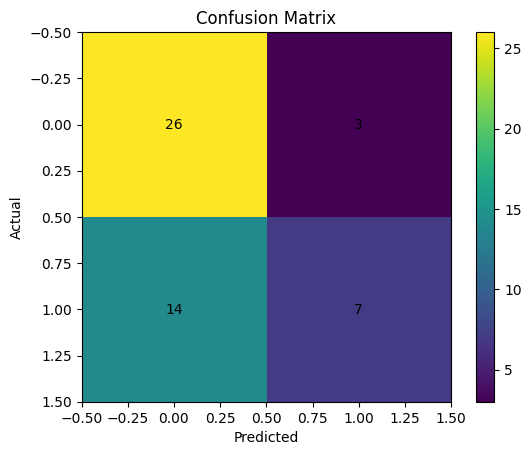

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(cm)

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

STEP 16: Experiment Function

In [ ]:
def train_and_evaluate(model):
    train_model(model)
    return evaluate_model(model)

STEP 17: Experiment 1 (Freeze BERT)

In [ ]:
model_exp1 = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2
)

model_exp1.config.problem_type = "single_label_classification"

for param in model_exp1.bert.parameters():
    param.requires_grad = False

model_exp1.to(device)

acc1, p1, r1, f1_1, _ = train_and_evaluate(model_exp1)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


STEP 18: Experiment 2 (Last 2 Layers)

In [ ]:
model_exp2 = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2
)

model_exp2.config.problem_type = "single_label_classification"

for param in model_exp2.bert.parameters():
    param.requires_grad = False

for name, param in model_exp2.bert.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True

model_exp2.to(device)

acc2, p2, r2, f2, _ = train_and_evaluate(model_exp2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


STEP 19: Graph Comparison

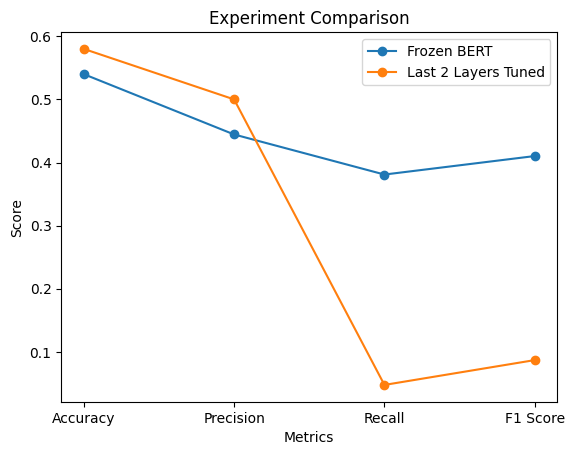

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

exp1_scores = [acc1, p1, r1, f1_1]
exp2_scores = [acc2, p2, r2, f2]

x = range(len(metrics))

plt.figure()
plt.plot(x, exp1_scores, marker='o', label="Frozen BERT")
plt.plot(x, exp2_scores, marker='o', label="Last 2 Layers Tuned")

plt.xticks(x, metrics)
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Experiment Comparison")
plt.legend()
plt.show()